# Code for analysing party program data

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotx
import ast

In [6]:
df = pd.read_csv('blogs_classified.csv', index_col=0)
df.head()

,company,title,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits
0,abn amro,ABN AMRO biedt bedrijven complete bescherming ...,ABN AMRO biedt midden- en grootbedrijf complet...,no,[],[],[],0,0,['facebook']
1,abn amro,Kunstmatige intelligentie_ Vriend of vijand_ _...,Kunstmatige intelligentie: Vriend of vijand?\n...,yes,[],"['ai', 'algoritmes', 'kunstmatige intelligenti...","['ai', 'algoritmes', 'kunstmatige intelligenti...",0,22,"['apple', 'facebook', 'ibm', 'microsoft']"
2,abn amro,Samen sterk tegen cyberaanvallen van morgen _ ...,Samen sterk tegen cyberaanvallen van morgen\nN...,yes,[],['ai'],['ai'],0,2,['facebook']
3,abn amro,Van digitale assistent tot virtuele BFF _ ABN ...,Van digitale assistent tot virtuele BFF\nBlog\...,yes,[],"['ai', 'artificial intelligence', 'chatbot', '...","['ai', 'artificial intelligence', 'chatbot', '...",0,16,"['apple', 'facebook', 'microsoft']"
4,accenture,Beyond the Hype_ Why Agentic AI is Closer Than...,BLOG\nBeyond the hype:\nWhy agentic AI is\nclo...,yes,['ai'],"['ai', 'chatgpt', 'llms']","['ai', 'chatgpt', 'llms']",1,59,"['apple', 'google', 'nvidia']"


In [ ]:
# make sure it both lists
df['matched_keywords_all'] = df['matched_keywords_all'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df['company_hits'] = df['company_hits'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [12]:
# combine the two lists into one
df['matched_keywords_all'] = df.apply(
    lambda row: list(set(row['matched_keywords_all'] + row['company_hits'])), axis=1
)

In [13]:
df.head()

,company,title,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits
0,abn amro,ABN AMRO biedt bedrijven complete bescherming ...,ABN AMRO biedt midden- en grootbedrijf complet...,no,[],[],[facebook],0,0,[facebook]
1,abn amro,Kunstmatige intelligentie_ Vriend of vijand_ _...,Kunstmatige intelligentie: Vriend of vijand?\n...,yes,[],"['ai', 'algoritmes', 'kunstmatige intelligenti...","[kunstmatige intelligentie, facebook, ai, algo...",0,22,"[apple, facebook, ibm, microsoft]"
2,abn amro,Samen sterk tegen cyberaanvallen van morgen _ ...,Samen sterk tegen cyberaanvallen van morgen\nN...,yes,[],['ai'],"[facebook, ai]",0,2,[facebook]
3,abn amro,Van digitale assistent tot virtuele BFF _ ABN ...,Van digitale assistent tot virtuele BFF\nBlog\...,yes,[],"['ai', 'artificial intelligence', 'chatbot', '...","[kunstmatige intelligentie, machine learning, ...",0,16,"[apple, facebook, microsoft]"
4,accenture,Beyond the Hype_ Why Agentic AI is Closer Than...,BLOG\nBeyond the hype:\nWhy agentic AI is\nclo...,yes,['ai'],"['ai', 'chatgpt', 'llms']","[ai, google, llms, nvidia, chatgpt, apple]",1,59,"[apple, google, nvidia]"


In [14]:
# keep ai related programs only
df_ai_only = df[df['ai_related'] == 'yes']
df_ai_only

,company,title,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits
1,abn amro,Kunstmatige intelligentie_ Vriend of vijand_ _...,Kunstmatige intelligentie: Vriend of vijand?\n...,yes,[],"['ai', 'algoritmes', 'kunstmatige intelligenti...","[kunstmatige intelligentie, facebook, ai, algo...",0,22,"[apple, facebook, ibm, microsoft]"
2,abn amro,Samen sterk tegen cyberaanvallen van morgen _ ...,Samen sterk tegen cyberaanvallen van morgen\nN...,yes,[],['ai'],"[facebook, ai]",0,2,[facebook]
3,abn amro,Van digitale assistent tot virtuele BFF _ ABN ...,Van digitale assistent tot virtuele BFF\nBlog\...,yes,[],"['ai', 'artificial intelligence', 'chatbot', '...","[kunstmatige intelligentie, machine learning, ...",0,16,"[apple, facebook, microsoft]"
4,accenture,Beyond the Hype_ Why Agentic AI is Closer Than...,BLOG\nBeyond the hype:\nWhy agentic AI is\nclo...,yes,['ai'],"['ai', 'chatgpt', 'llms']","[ai, google, llms, nvidia, chatgpt, apple]",1,59,"[apple, google, nvidia]"
5,accenture,Embracing Gen AI at Work _ News Article _ Acce...,NEWS ARTICLE\nEmbracing Gen\nAI at work\n10-MI...,yes,['ai'],"['ai', 'artificial intelligence', 'chatgpt', '...","[ai, llms, artificial intelligence, chatgpt, llm]",1,58,[]
...,...,...,...,...,...,...,...,...,...,...
74,tno,How TNO is leading the drive towards sovereign...,Geselecteerde taal: EN\nSustainable\nHealthy\n...,yes,['ai'],"['ai', 'artificial intelligence', 'gpt', 'larg...","[facebook, ai, gpt, artificial intelligence, l...",1,54,[facebook]
75,tno,Large dataset news organizations for Dutch AI ...,Geselecteerde taal: EN\nSustainable\nHealthy\n...,yes,"['ai', 'gpt']","['ai', 'artificial intelligence', 'gpt']","[gpt, facebook, artificial intelligence, ai]",2,28,[facebook]
76,tno,New AI Lab for effective and responsible overs...,Geselecteerde taal: EN\nSustainable\nHealthy\n...,yes,['ai'],"['ai', 'artificial intelligence', 'gpt']","[gpt, facebook, artificial intelligence, ai]",1,21,[facebook]
77,ziggo,From Gut Feeling to Data-Driven Decisions_ How...,From Gut Feeling to Data-Driven\nFrom Gut Feel...,yes,['ai'],"['ai', 'artificial intelligence', 'bard', 'cha...","[ai, google, gemini, artificial intelligence, ...",1,41,[google]


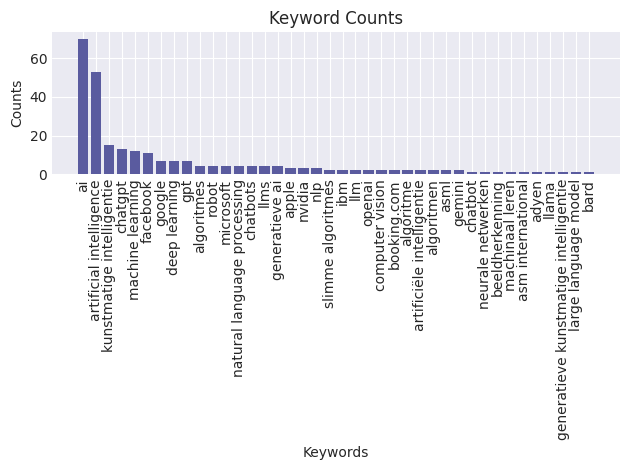

In [21]:
import ast
import matplotlib.pyplot as plt
import matplotx

# exclude '[]' entries and make an explicit copy
df_no_brackets = df[df['matched_keywords_all'] != '[]'].copy()

# safely convert strings to lists
def safe_eval(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

df_no_brackets['matched_keywords_all'] = (
    df_no_brackets['matched_keywords_all'].apply(safe_eval)
)

# count keywords
keyword_counts = {}

for keywords in df_no_brackets['matched_keywords_all']:
    for keyword in keywords:
        keyword_counts[keyword] = keyword_counts.get(keyword, 0) + 1

# sort by frequency
sorted_keyword_counts = dict(
    sorted(keyword_counts.items(), key=lambda item: item[1], reverse=True)
)

# plot
plt.style.use(matplotx.styles.pacoty)
plt.bar(sorted_keyword_counts.keys(), sorted_keyword_counts.values())
plt.xticks(rotation=90)
plt.xlabel('Keywords')
plt.ylabel('Counts')
plt.title('Keyword Counts')
plt.tight_layout()
plt.show()


In [22]:
import re
import ast
import pandas as pd

def _norm_matched_keywords(val):
    """
    Normalize matched_keywords_all into a list[str].
    Accepts: list/set/tuple, stringified list (e.g. "['ai','ml']"),
             or comma-separated string ("ai, machine learning").
    """
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return []
    if isinstance(val, (list, set, tuple)):
        kws = list(val)
    elif isinstance(val, str):
        s = val.strip()
        if not s:
            return []
        # Try to parse stringified list
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, set, tuple)):
                kws = list(parsed)
            else:
                # fallback: treat as comma-separated
                kws = [x.strip() for x in s.split(",") if x.strip()]
        except Exception:
            kws = [x.strip() for x in s.split(",") if x.strip()]
    else:
        return []

    # clean, dedupe, keep phrases
    out = []
    seen = set()
    for k in kws:
        if not isinstance(k, str):
            continue
        k2 = k.strip()
        if not k2:
            continue
        kl = k2.lower()
        if kl not in seen:
            seen.add(kl)
            out.append(k2)
    return out

def _extract_windows(text, keywords, window=5, max_snippets=5):
    """
    Build a plain-text section composed of ±window words around each keyword hit.
    Returns: (section_text, spans, n_matches)
    """
    if not isinstance(text, str) or not text.strip():
        return "", [], 0
    keywords = _norm_matched_keywords(keywords)
    if not keywords:
        return "", [], 0

    # Safer "word boundary" for phrases: (?<!\w) ... (?!\w)
    # (handles multi-word phrases and punctuation better than \b ... \b)
    alts = [re.escape(k) for k in keywords]
    pattern = r'(?<!\w)(?:' + '|'.join(alts) + r')(?!\w)'
    flags = re.IGNORECASE

    matches = list(re.finditer(pattern, text, flags))
    if not matches:
        return "", [], 0

    # Word spans to take ±window words
    word_spans = [(m.start(), m.end()) for m in re.finditer(r'\S+', text)]

    def word_index_for_pos(pos):
        # small linear scan is fine for typical lengths
        for i, (s, e) in enumerate(word_spans):
            if s <= pos < e:
                return i
        # if match starts on whitespace, snap to next word
        for i, (s, e) in enumerate(word_spans):
            if pos < e:
                return i
        return len(word_spans) - 1 if word_spans else 0

    spans = []
    for m in matches:
        wi = word_index_for_pos(m.start())
        start_w = max(0, wi - window)
        end_w   = min(len(word_spans), wi + window + 1)
        start_c = word_spans[start_w][0]
        end_c   = word_spans[end_w - 1][1]

        if spans and start_c <= spans[-1][1]:
            spans[-1] = (spans[-1][0], max(spans[-1][1], end_c))
        else:
            spans.append((start_c, end_c))

    spans = spans[:max_snippets]

    parts = []
    for i, (s, e) in enumerate(spans):
        prefix = '...' if (i == 0 and s > 0) else ''
        suffix = '...' if (i == len(spans)-1 and e < len(text)) else ''
        parts.append(prefix + text[s:e].strip() + suffix)

    section_text = ' '.join(parts)
    return section_text, spans, len(matches)

def add_relevant_section(df, body_col='body', matched_col='matched_keywords_all',
                         window=5, max_snippets=5):
    """
    Adds:
      - relevant_section (plain text)
      - relevant_section_spans (char spans)
      - n_keyword_matches
      - relevant_len_chars
      - relevant_len_words
    """
    results = df.apply(
        lambda r: _extract_windows(
            str(r[body_col]) if pd.notna(r.get(body_col)) else "",
            r.get(matched_col),
            window,
            max_snippets
        ),
        axis=1
    )
    df['relevant_section']       = results.map(lambda t: t[0])
    df['relevant_section_spans'] = results.map(lambda t: t[1])
    df['n_keyword_matches']      = results.map(lambda t: t[2])
    df['relevant_len_chars']     = df['relevant_section'].str.len()
    df['relevant_len_words']     = df['relevant_section'].str.count(r'\b\w+\b')
    return df


In [44]:
df_relevant = add_relevant_section(df, body_col='body', matched_col='matched_keywords_all', window=30)
df_relevant

,company,title,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits,relevant_section,relevant_section_spans,n_keyword_matches,relevant_len_chars,relevant_len_words,total_len_words
0,abn amro,ABN AMRO biedt bedrijven complete bescherming ...,ABN AMRO biedt midden- en grootbedrijf complet...,no,[],[],[facebook],0,0,[facebook],"...Group Economics\nFeedback\n12/4/25, 5:51 PM...","[(4293, 4922)]",1,635,96,754
1,abn amro,Kunstmatige intelligentie_ Vriend of vijand_ _...,Kunstmatige intelligentie: Vriend of vijand?\n...,yes,[],"['ai', 'algoritmes', 'kunstmatige intelligenti...","[kunstmatige intelligentie, facebook, ai, algo...",0,22,"[apple, facebook, ibm, microsoft]",Kunstmatige intelligentie: Vriend of vijand?\n...,"[(0, 228), (540, 1267), (1496, 3619), (4495, 5...",27,4814,719,1270
2,abn amro,Samen sterk tegen cyberaanvallen van morgen _ ...,Samen sterk tegen cyberaanvallen van morgen\nN...,yes,[],['ai'],"[facebook, ai]",0,2,[facebook],...nieuwe\nDDoS aanvallen kunnen worden voorsp...,"[(2375, 3086), (4624, 5202)]",3,1296,196,799
3,abn amro,Van digitale assistent tot virtuele BFF _ ABN ...,Van digitale assistent tot virtuele BFF\nBlog\...,yes,[],"['ai', 'artificial intelligence', 'chatbot', '...","[kunstmatige intelligentie, machine learning, ...",0,16,"[apple, facebook, microsoft]",Van digitale assistent tot virtuele BFF\nBlog\...,"[(0, 263), (399, 1763), (1921, 2301), (3850, 4...",19,3390,522,1345
4,accenture,Beyond the Hype_ Why Agentic AI is Closer Than...,BLOG\nBeyond the hype:\nWhy agentic AI is\nclo...,yes,['ai'],"['ai', 'chatgpt', 'llms']","[ai, google, llms, nvidia, chatgpt, apple]",1,59,"[apple, google, nvidia]",BLOG\nBeyond the hype:\nWhy agentic AI is\nclo...,"[(0, 719), (858, 3401), (4444, 5019), (5390, 6...",64,5970,975,1864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,tno,How TNO is leading the drive towards sovereign...,Geselecteerde taal: EN\nSustainable\nHealthy\n...,yes,['ai'],"['ai', 'artificial intelligence', 'gpt', 'larg...","[facebook, ai, gpt, artificial intelligence, l...",1,54,[facebook],Geselecteerde taal: EN\nSustainable\nHealthy\n...,"[(0, 6526), (6543, 7162), (7595, 7861)]",55,7416,1187,1245
75,tno,Large dataset news organizations for Dutch AI ...,Geselecteerde taal: EN\nSustainable\nHealthy\n...,yes,"['ai', 'gpt']","['ai', 'artificial intelligence', 'gpt']","[gpt, facebook, artificial intelligence, ai]",2,28,[facebook],Geselecteerde taal: EN\nSustainable\nHealthy\n...,"[(0, 661), (769, 2486), (2490, 4614), (5006, 5...",29,4774,744,814
76,tno,New AI Lab for effective and responsible overs...,Geselecteerde taal: EN\nSustainable\nHealthy\n...,yes,['ai'],"['ai', 'artificial intelligence', 'gpt']","[gpt, facebook, artificial intelligence, ai]",1,21,[facebook],Geselecteerde taal: EN\nSustainable\nHealthy\n...,"[(0, 767), (1039, 1492), (1495, 2024), (2205, ...",22,3720,563,737
77,ziggo,From Gut Feeling to Data-Driven Decisions_ How...,From Gut Feeling to Data-Driven\nFrom Gut Feel...,yes,['ai'],"['ai', 'artificial intelligence', 'bard', 'cha...","[ai, google, gemini, artificial intelligence, ...",1,41,[google],From Gut Feeling to Data-Driven\nFrom Gut Feel...,"[(0, 1444), (1510, 2214), (2276, 3637), (3741,...",47,5832,918,1156


In [45]:
# add total word count of body column
df_relevant['total_len_words'] = df_relevant['body'].str.count(r'\b\w+\b')

In [46]:
df_relevant['relevant_len_words'] = df_relevant['relevant_section'].str.count(r'\b\w+\b')

In [47]:
df_relevant.head()

,company,title,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits,relevant_section,relevant_section_spans,n_keyword_matches,relevant_len_chars,relevant_len_words,total_len_words
0,abn amro,ABN AMRO biedt bedrijven complete bescherming ...,ABN AMRO biedt midden- en grootbedrijf complet...,no,[],[],[facebook],0,0,[facebook],"...Group Economics\nFeedback\n12/4/25, 5:51 PM...","[(4293, 4922)]",1,635,96,754
1,abn amro,Kunstmatige intelligentie_ Vriend of vijand_ _...,Kunstmatige intelligentie: Vriend of vijand?\n...,yes,[],"['ai', 'algoritmes', 'kunstmatige intelligenti...","[kunstmatige intelligentie, facebook, ai, algo...",0,22,"[apple, facebook, ibm, microsoft]",Kunstmatige intelligentie: Vriend of vijand?\n...,"[(0, 228), (540, 1267), (1496, 3619), (4495, 5...",27,4814,719,1270
2,abn amro,Samen sterk tegen cyberaanvallen van morgen _ ...,Samen sterk tegen cyberaanvallen van morgen\nN...,yes,[],['ai'],"[facebook, ai]",0,2,[facebook],...nieuwe\nDDoS aanvallen kunnen worden voorsp...,"[(2375, 3086), (4624, 5202)]",3,1296,196,799
3,abn amro,Van digitale assistent tot virtuele BFF _ ABN ...,Van digitale assistent tot virtuele BFF\nBlog\...,yes,[],"['ai', 'artificial intelligence', 'chatbot', '...","[kunstmatige intelligentie, machine learning, ...",0,16,"[apple, facebook, microsoft]",Van digitale assistent tot virtuele BFF\nBlog\...,"[(0, 263), (399, 1763), (1921, 2301), (3850, 4...",19,3390,522,1345
4,accenture,Beyond the Hype_ Why Agentic AI is Closer Than...,BLOG\nBeyond the hype:\nWhy agentic AI is\nclo...,yes,['ai'],"['ai', 'chatgpt', 'llms']","[ai, google, llms, nvidia, chatgpt, apple]",1,59,"[apple, google, nvidia]",BLOG\nBeyond the hype:\nWhy agentic AI is\nclo...,"[(0, 719), (858, 3401), (4444, 5019), (5390, 6...",64,5970,975,1864


In [48]:
dropped = df_relevant.drop(columns=['body', 'ai_related', 'matched_keywords_title', 'matched_keywords_body', 'n_hits_title_total', 'n_hits_body_total', 'relevant_section_spans', 'relevant_len_chars'])


In [50]:
dropped = dropped.rename(columns={'relevant_section':'body'})

In [51]:
dropped.head()

,company,title,matched_keywords_all,company_hits,body,n_keyword_matches,relevant_len_words,total_len_words
0,abn amro,ABN AMRO biedt bedrijven complete bescherming ...,[facebook],[facebook],"...Group Economics\nFeedback\n12/4/25, 5:51 PM...",1,96,754
1,abn amro,Kunstmatige intelligentie_ Vriend of vijand_ _...,"[kunstmatige intelligentie, facebook, ai, algo...","[apple, facebook, ibm, microsoft]",Kunstmatige intelligentie: Vriend of vijand?\n...,27,719,1270
2,abn amro,Samen sterk tegen cyberaanvallen van morgen _ ...,"[facebook, ai]",[facebook],...nieuwe\nDDoS aanvallen kunnen worden voorsp...,3,196,799
3,abn amro,Van digitale assistent tot virtuele BFF _ ABN ...,"[kunstmatige intelligentie, machine learning, ...","[apple, facebook, microsoft]",Van digitale assistent tot virtuele BFF\nBlog\...,19,522,1345
4,accenture,Beyond the Hype_ Why Agentic AI is Closer Than...,"[ai, google, llms, nvidia, chatgpt, apple]","[apple, google, nvidia]",BLOG\nBeyond the hype:\nWhy agentic AI is\nclo...,64,975,1864


In [61]:
import re
import pandas as pd
from html import escape
from IPython.display import display, HTML

def inspect_ai_related(df, num_samples=30, random_state=42):
    """
    Displays random samples with highlighted *matched* keywords.
    Uses df['matched_keywords_all'] per row instead of a global keyword list.
    Works even if 'title' column is missing.
    """

    # --- sanity checks ---
    if 'ai_related' not in df.columns:
        raise KeyError("DataFrame must contain an 'ai_related' column.")
    if 'body' not in df.columns:
        raise KeyError("DataFrame must contain a 'body' column.")
    if 'matched_keywords_all' not in df.columns:
        raise KeyError("DataFrame must contain 'matched_keywords_all'.")

    # --- sample ---
    n = min(num_samples, len(df))
    samples = df.sample(n=n, random_state=random_state)

    # --- internal highlight function ---
    def highlight_keywords(text, keywords):
        if pd.isna(text):
            return ""
        s = str(text)

        if not isinstance(keywords, (set, list)):
            raise ValueError("Keywords must be a set or list")
        kws = {str(w).strip().lower() for w in keywords if str(w).strip()}
        if not kws:
            return s

        # sort by length to avoid partial overshadowing
        ordered = sorted(kws, key=len, reverse=True)

        # custom boundary: match even inside hyphenated words
        def make_pattern(word):
            return rf'(?<![A-Za-z0-9]){re.escape(word)}(?![A-Za-z0-9])'

        combined = "|".join(make_pattern(w) for w in ordered)
        regex = re.compile(combined, flags=re.IGNORECASE)

        def repl(m):
            kw = m.group(0)
            return f'<span style="font-size:1.5em; font-weight:bold; color:green;">{escape(kw)}</span>'

        return regex.sub(repl, s)

    # --- display samples ---
    for idx, row in samples.iterrows():
        ai_val = row['ai_related']
        body   = row['body']
        title  = row.get('title', None)

        # --- use the actually matched keywords in this row ---
        matched_keywords = row.get('matched_keywords_all', [])
        if isinstance(matched_keywords, (list, set, tuple)):
            row_terms = {str(x).lower() for x in matched_keywords}
        else:
            row_terms = {str(matched_keywords).lower()} if matched_keywords else set()

        # --- highlight ---
        highlighted_body  = highlight_keywords(body, row_terms)
        highlighted_title = highlight_keywords(title, row_terms) if title is not None else None

        # --- header ---
        header_html = (
            f'<div style="margin:0.5em 0;">'
            f'<strong>Index:</strong> {idx} &nbsp; | &nbsp; '
            f'<strong>ai_related:</strong> {ai_val}'
        )
        if matched_keywords:
            header_html += f'<br><strong>matched keywords:</strong> {matched_keywords}'
        header_html += '</div>'

        # --- display ---
        display(HTML(header_html))
        if highlighted_title:
            display(HTML(f'<h3 style="margin:0.2em 0;">{highlighted_title}</h3>'))
        display(HTML(f'<div style="line-height:1.5;">{highlighted_body}</div>'))
        display(HTML('<hr>'))

    print(f"Displayed {n} random articles (with row-specific matched keywords highlighted).")
    return samples

In [38]:
df_relevant.to_csv('relevant_corp_blogs.csv')

In [60]:
dropped.head()

,company,title,matched_keywords_all,company_hits,body,n_keyword_matches,relevant_len_words,total_len_words,ai_related
0,abn amro,ABN AMRO biedt bedrijven complete bescherming ...,[facebook],[facebook],"...Group Economics\nFeedback\n12/4/25, 5:51 PM...",1,96,754,yes
1,abn amro,Kunstmatige intelligentie_ Vriend of vijand_ _...,"[kunstmatige intelligentie, facebook, ai, algo...","[apple, facebook, ibm, microsoft]",Kunstmatige intelligentie: Vriend of vijand?\n...,27,719,1270,yes
2,abn amro,Samen sterk tegen cyberaanvallen van morgen _ ...,"[facebook, ai]",[facebook],...nieuwe\nDDoS aanvallen kunnen worden voorsp...,3,196,799,yes
3,abn amro,Van digitale assistent tot virtuele BFF _ ABN ...,"[kunstmatige intelligentie, machine learning, ...","[apple, facebook, microsoft]",Van digitale assistent tot virtuele BFF\nBlog\...,19,522,1345,yes
4,accenture,Beyond the Hype_ Why Agentic AI is Closer Than...,"[ai, google, llms, nvidia, chatgpt, apple]","[apple, google, nvidia]",BLOG\nBeyond the hype:\nWhy agentic AI is\nclo...,64,975,1864,yes


In [58]:
#add column
dropped['ai_related'] = 'yes'

In [62]:
inspect_ai_related(dropped, num_samples=1)

Displayed 1 random articles (with row-specific matched keywords highlighted).


,company,title,matched_keywords_all,company_hits,body,n_keyword_matches,relevant_len_words,total_len_words,ai_related
30,ing,ING BeleggersBarometer_ Beleggers zien meer ka...,"[kunstmatige intelligentie, ai, gpt, asm inter...","[adyen, asm international, asml, nvidia]","Zaterdag 29 juni 2024, 08:00 CEST\nBeleggers z...",29,749,935,yes


In [63]:
# average words in relevant sections
dropped['relevant_len_words'].mean()

np.float64(607.1645569620254)

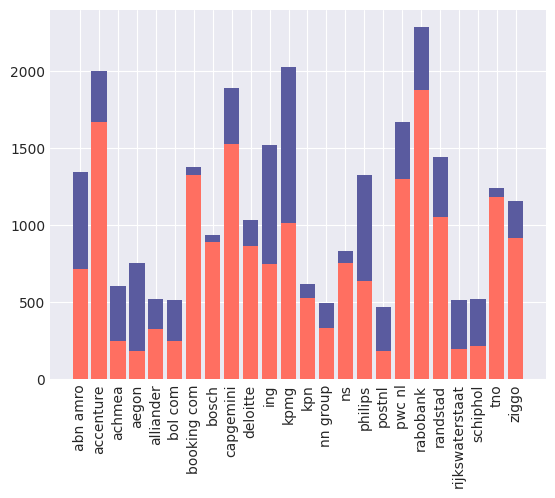

In [66]:
# show barplot relevant vs total word count
plt.style.use(matplotx.styles.pacoty)
plt.bar(dropped['company'], dropped['total_len_words'], label='Total Words')
plt.bar(dropped['company'], dropped['relevant_len_words'], label='Relevant Words')
plt.xticks(rotation=90)
plt.show()



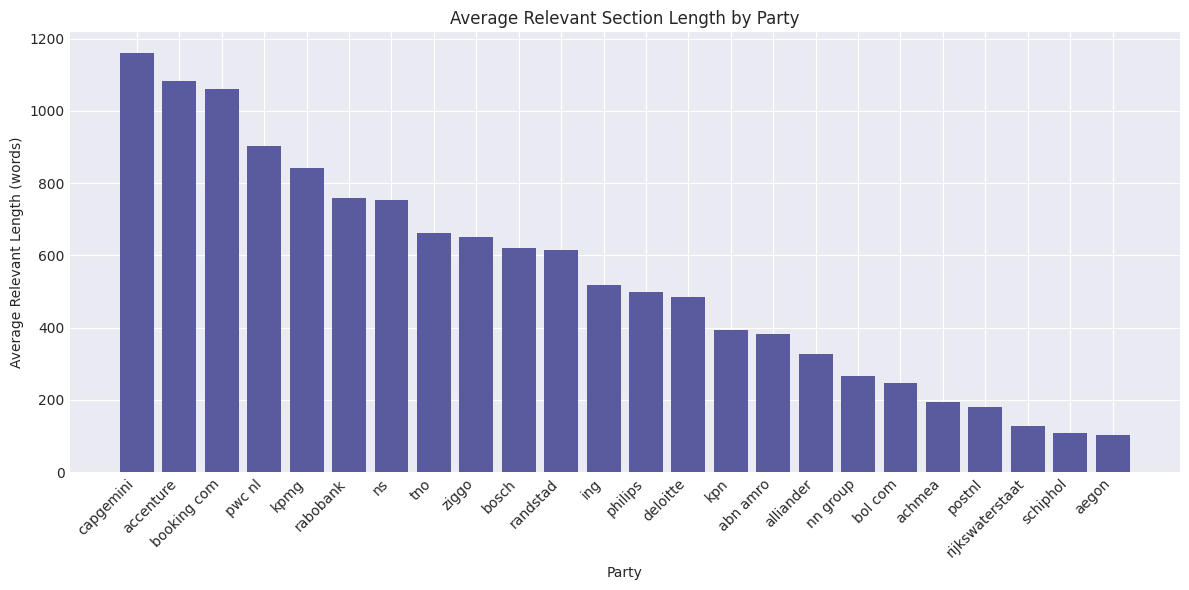

In [68]:


length_by_party = (
    df.groupby('company')['relevant_len_words']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

length_by_party


plt.style.use(matplotx.styles.pacoty)
plt.figure(figsize=(12,6))  # make the plot wider

plt.bar(length_by_party['company'], length_by_party['relevant_len_words'])

plt.xlabel('Party')
plt.ylabel('Average Relevant Length (words)')
plt.title('Average Relevant Section Length by Party')

plt.xticks(rotation=45, ha='right')  # rotate labels + right-align so they don’t overlap
plt.tight_layout()                  # automatically adjust margins

plt.show()



